<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/United_States_Population_Density_County_2020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

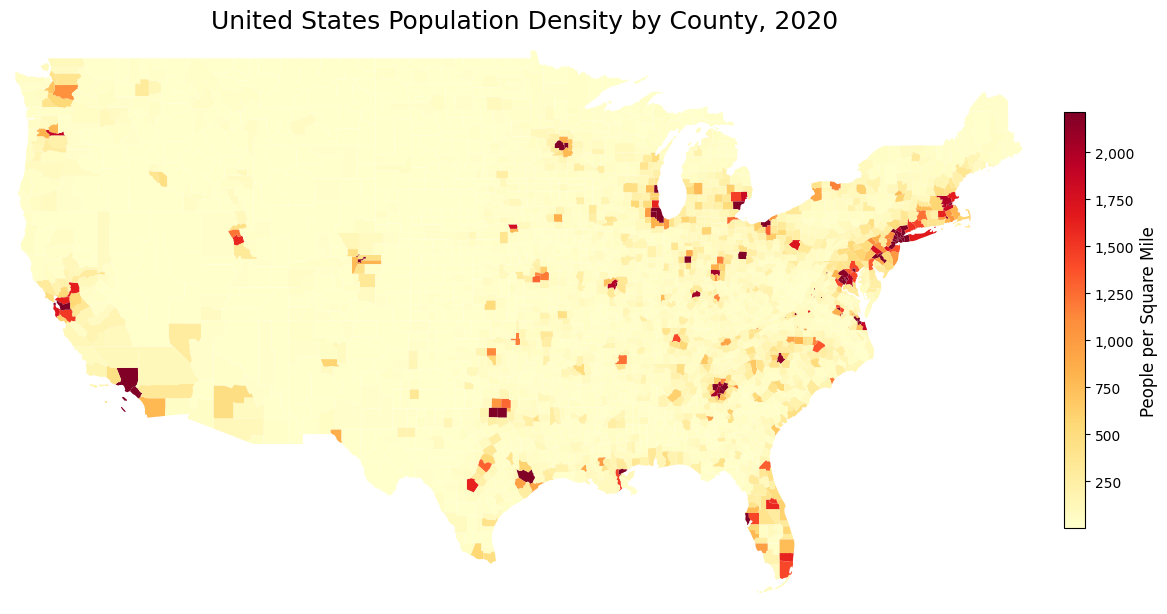

In [2]:
# Run once
# !pip install geopandas pandas numpy matplotlab
# Link to download page: https://data.census.gov./table/DECENNIALPL2020.P1?q=P1+total+population+2020+county
# Use this csv file: DECENNIALPL2020.P1-Column-Metadata.csv
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# Read Census population CSV
file = "/content/DECENNIALPL2020.P1-Data.csv"

pop_data = pd.read_csv(file)

# Remove first row if it is a label/description row
pop_data = pop_data[pop_data["GEO_ID"] != "Geography"].copy()

# Keep important columns
population_df = pop_data[[
    "GEO_ID",
    "NAME",
    "P1_001N"
]].copy()

# Rename population column
population_df = population_df.rename(columns={
    "P1_001N": "population"
})

# Make population numeric
population_df["population"] = pd.to_numeric(
    population_df["population"],
    errors="coerce"
)

# Get county FIPS from GEO_ID
# Example: 0500000US01001 -> 01001
population_df["GEOID"] = population_df["GEO_ID"].str[-5:]

# Read county shapefile
county_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_20m.zip"

counties = gpd.read_file(county_url)

# Merge county boundaries with population data
merged = counties.merge(
    population_df,
    on="GEOID",
    how="left"
)

# Remove Alaska, Hawaii, Puerto Rico, and territories
lower48 = merged[
    ~merged["STUSPS"].isin(["AK", "HI", "PR", "GU", "VI", "MP", "AS"])
].copy()

# Calculate county land area in square miles
# ALAND is land area in square meters
lower48["land_area_sq_miles"] = lower48["ALAND"] / 2_589_988.11

# Calculate population density
lower48["population_density"] = (
    lower48["population"] / lower48["land_area_sq_miles"]
)

# Remove missing or infinite values
lower48 = lower48[
    lower48["population_density"].notna() &
    np.isfinite(lower48["population_density"])
].copy()

# Make colors look better by ignoring extreme outliers
vmin = lower48["population_density"].quantile(0.02)
vmax = lower48["population_density"].quantile(0.98)

# Make map
fig, ax = plt.subplots(figsize=(16, 9))

lower48.plot(
    column="population_density",
    cmap="YlOrRd",
    legend=True,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax,
    legend_kwds={
        "label": "People per Square Mile",
        "orientation": "vertical",
        "shrink": 0.6,
        "pad": 0.02
    }
)

# Make colorbar numbers easier to read
cbar = ax.get_figure().axes[-1]

cbar.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

cbar.set_ylabel("People per Square Mile", fontsize=12)

ax.set_title("United States Population Density by County, 2020", fontsize=18)
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")

plt.show()